=== 5 Baris Pertama Dataset ===
   magnitude  depth  cdi  mmi   sig  alert
0        7.0   14.0  8.0  7.0   0.0  green
1        6.9   25.0  4.0  4.0 -33.0  green
2        7.0  579.0  3.0  3.0 -13.0  green
3        7.3   37.0  5.0  5.0  65.0  green
4        6.6  624.0  0.0  2.0 -98.0  green

Cek Missing Values:
 magnitude    0
depth        0
cdi          0
mmi          0
sig          0
alert        0
dtype: int64
------------------------------------------------------------
Jumlah data latih: 910
Jumlah data uji  : 390
------------------------------------------------------------
Memulai pelatihan model SVM (kernel='rbf')...
Pelatihan model selesai.
------------------------------------------------------------
=== Laporan Klasifikasi ===
              precision    recall  f1-score   support

       green       0.96      0.78      0.86        98
      orange       0.74      0.64      0.69        97
         red       0.69      0.95      0.80        98
      yellow       0.79      0.75      0

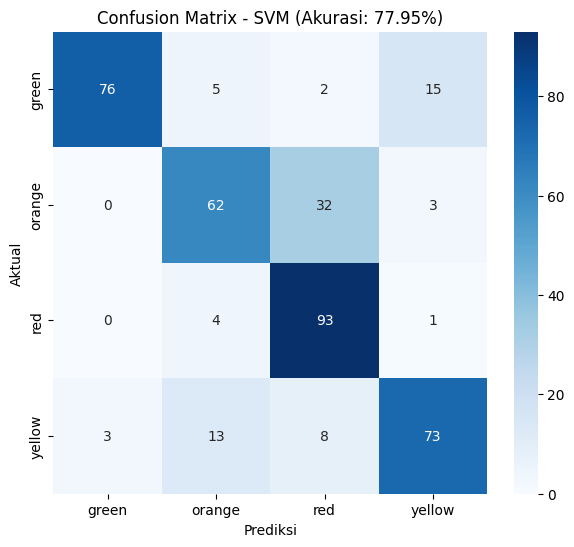


Prediksi 'alert' untuk data baru: yellow


In [ ]:
# ==========================================
# Support Vector Machine (SVM) untuk Prediksi Alert Gempa
# Versi dengan Normalisasi + Evaluasi Lengkap
# ==========================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Memuat Dataset
file_path = 'earthquake_alert_balanced_dataset.csv'
df = pd.read_csv(file_path, delimiter=';')

print("=== 5 Baris Pertama Dataset ===")
print(df.head())
print("\nCek Missing Values:\n", df.isnull().sum())
print("-" * 60)

# 2. Persiapan Data
X = df.drop('alert', axis=1)
y = df['alert']

# Encode target (ubah green/yellow/red/orange -> angka)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Normalisasi fitur (karena SVM sensitif terhadap skala data)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Bagi data menjadi train & test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

print(f"Jumlah data latih: {len(X_train)}")
print(f"Jumlah data uji  : {len(X_test)}")
print("-" * 60)

# 3. Melatih Model SVM
print("Memulai pelatihan model SVM (kernel='rbf')...")
svm_model = SVC(kernel='rbf', C=2, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)
print("Pelatihan model selesai.")
print("-" * 60)

# 4. Evaluasi Model
y_pred = svm_model.predict(X_test)

print("=== Laporan Klasifikasi ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("-" * 60)

# Matriks Kebingungan
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
print("Akurasi Model:", round(acc * 100, 2), "%")
print("\nMatriks Kebingungan:\n", cm)

# 5. Visualisasi Confusion Matrix
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - SVM (Akurasi: {round(acc*100,2)}%)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

# 6. Contoh Prediksi Baru
new_data = pd.DataFrame([[6.8, 20.0, 8.0, 7.0, -101.0]], columns=X.columns)
new_data_scaled = scaler.transform(new_data)
prediction = svm_model.predict(new_data_scaled)
print(f"\nPrediksi 'alert' untuk data baru: {le.inverse_transform(prediction)[0]}") 